# Script for measuring nosie statistics of a test image

In [ ]:
from pathlib import Path
import glob
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
import matplotlib.lines as mlines
from matplotlib.lines import Line2D

from scipy.stats import bootstrap, median_abs_deviation, mode

from astropy.io import fits
from astropy.wcs import WCS
from astropy.stats import sigma_clip
from astropy.visualization import (
    PercentileInterval,
    ImageNormalize,
    SqrtStretch,
    simple_norm,
)
from astropy.cosmology import Planck15 as cosmo
from astropy.cosmology import FlatLambdaCDM

from photutils.aperture import CircularAnnulus

from nicl.mask import (
    create_bcg_mask,
    create_icl_mask,
    create_faint_mask,
    create_object_mask,
)
from nicl.background import get_background
from nicl.testing import create_test_background, create_test_mask, correlate_pixels
from nicl.euclid.mask import create_combined_nir_mask

h = 0.7
cosmo = FlatLambdaCDM(H0=h * 100, Om0=0.3)

In [ ]:
def plot_test_images(random, background, random_with_background, mask, circles=True):
    fig, ax = plt.subplots(1, 4, figsize=(12, 6))
    for a in ax:
        a.set_xticks([])
        a.set_yticks([])
    vmin, vmax = np.percentile(random, (0.1, 99.9))
    ax[0].imshow(random, vmin=vmin, vmax=vmax, cmap="seismic", interpolation="none")
    ax[1].imshow(background, vmin=vmin, vmax=vmax, cmap="seismic", interpolation="none")
    ax[2].imshow(
        random_with_background,
        vmin=vmin,
        vmax=vmax,
        cmap="seismic",
        interpolation="none",
    )
    ax[3].imshow(mask, cmap="seismic", interpolation="none")
    if circles:
        x = 120
        for i, radius in enumerate((10, 20, 40, 80)):
            circle = plt.Circle((x + radius, 150), radius, ec="w", fc="none", lw=5)
            ax[1].add_patch(circle)
            circle = plt.Circle((x + radius, 150), radius, ec="k", fc="none")
            ax[1].add_patch(circle)
            rlabel = "r=" if i == 0 else ""
            x += 2 * radius + 160
    plt.tight_layout()


def save_fits(data, filename):
    hdu = fits.PrimaryHDU(data)
    hdu.writeto(filename, overwrite=True)

In [ ]:
def measure_noise_in_circular_annuli(
    image_path,
    object_mask_path,
    profile_path,
    hdul_index=0,
    pixelscale=0.3,
    core_mask_path=None,
    rad_limit_annulus=None,
    verbose=None,
    num_points=50,
    output_path=None,
    show_diagnostic_plots=True,
    save_diagnostics=False,
    show_annuli=False,
    zp=23.9,
):
    from photutils.aperture import CircularAnnulus
    from photutils.utils import calc_total_error
    from matplotlib.colors import Normalize
    from scipy.stats import median_abs_deviation
    from astropy.stats import sigma_clip
    from astropy.visualization import simple_norm
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import matplotlib.lines as mlines
    import glob
    import numpy as np
    import pandas as pd
    from pathlib import Path
    from astropy.io import fits

    profiles = sorted(glob.glob(str(profile_path)))
    df_dict = {}
    for profile in profiles:
        filekey = profile.split("/")[-1].split("_")
        clusterid = filekey[0] + "_" + filekey[1]
        boxsize = (filekey[5].split(".")[0]) if len(filekey) > 4 else 0
        gs = f"_{filekey[filekey.index('gscale') + 1]}" if "gscale" in filekey else ""
        label = f"{clusterid}_{boxsize}{gs}"
        df_dict[label] = pd.read_csv(profile, skiprows=1)

    image = fits.open(image_path)[hdul_index].data
    object_mask = fits.open(object_mask_path)[0].data.astype(bool)
    core_mask = (
        fits.open(core_mask_path)[0].data.astype(bool)
        if core_mask_path
        else np.zeros_like(object_mask)
    )
    combined_mask = object_mask | core_mask | ~np.isfinite(image)
    masked_image = np.where(combined_mask, np.nan, image)

    prof = df_dict[label]
    prof["R"] = prof["R"] / pixelscale
    if rad_limit_annulus:
        prof = prof[prof["R"] < rad_limit_annulus]
    selected_annuli = sorted(set(prof["R"].values))
    first_radius = selected_annuli[0] if selected_annuli else 0
    r_max = max(selected_annuli) if selected_annuli else 0

    image_height, image_width = masked_image.shape
    valid_y, valid_x = np.where(~combined_mask)
    valid_points = np.column_stack((valid_x, valid_y))
    valid_points = valid_points[
        (valid_points[:, 0] > r_max)
        & (valid_points[:, 0] < image_width - r_max)
        & (valid_points[:, 1] > r_max)
        & (valid_points[:, 1] < image_height - r_max)
    ]

    flux_stats = []
    final_selected_points = []

    while len(final_selected_points) < num_points and valid_points.size > 0:
        x, y = valid_points[np.random.choice(len(valid_points))]
        x += np.random.uniform(-0.5, 0.5)
        y += np.random.uniform(-0.5, 0.5)

        annulus = CircularAnnulus((x, y), r_in=0.5, r_out=first_radius)
        test = annulus.to_mask(method="exact").multiply(masked_image)
        if np.count_nonzero(np.isfinite(test) & (test != 0)) == 0:
            continue

        final_selected_points.append((x, y))
        print(f"The noise profile is being extracted around point: {x:.1f}, {y:.1f}")

        for i in range(len(selected_annuli) - 1):
            r_in, r_out = selected_annuli[i], selected_annuli[i + 1]
            ann = (
                CircularAnnulus((x, y), r_in, r_out)
                .to_mask(method="center")
                .to_image(masked_image.shape)
            )
            values = masked_image[np.isfinite(masked_image) & (ann > 0)]

            stats = {
                "Centre_pixel": (x, y),
                "Inner_Radius_pix": r_in,
                "Outer_Radius_pix": r_out,
                "Inner_Radius_arcsec": r_in * pixelscale,
                "Outer_Radius_arcsec": r_out * pixelscale,
                "SMA_annulus_centre_pix": (r_in + r_out) / 2,
                "SMA_annulus_centre_arcsec": ((r_in + r_out) * pixelscale) / 2,
            }

            if len(values) == 0:
                stats.update(
                    {
                        key: np.nan
                        for key in [
                            "Mean_flux_annulus",
                            "Median_flux_annulus",
                            "Std_flux_annulus",
                            "Clipped_mean_flux_annulus",
                            "Clipped_median_flux_annulus",
                            "Clipped_Std_flux_annulus",
                            "Total_valid_pix_annulus",
                        ]
                    }
                )
            else:
                clipped = sigma_clip(values, sigma=3, cenfunc="median", maxiters=5)
                clipped_values = clipped.data[~clipped.mask]
                stats.update(
                    {
                        "Mean_flux_annulus": np.nanmean(values) / pixelscale**2,
                        "Median_flux_annulus": np.nanmedian(values) / pixelscale**2,
                        "Std_flux_annulus": np.nanstd(values)
                        if len(values) > 1
                        else np.nan,
                        "Clipped_mean_flux_annulus": np.nanmean(clipped_values)
                        / pixelscale**2,
                        "Clipped_median_flux_annulus": np.nanmedian(clipped_values)
                        / pixelscale**2,
                        "Clipped_Std_flux_annulus": np.nanstd(clipped_values)
                        if len(clipped_values) > 1
                        else np.nan,
                        "Total_valid_pix_annulus": len(values),
                    }
                )

            flux_stats.append(stats)

    flux_stats_df = pd.DataFrame(flux_stats)

    # Background subtraction
    flux_grouped = flux_stats_df.groupby("Centre_pixel")
    flux_combined = []
    for centre, group in flux_grouped:
        bkg_region = group[group["SMA_annulus_centre_arcsec"] > 1000]
        if bkg_region.empty:
            continue
        bkg = np.nanmean(bkg_region["Clipped_median_flux_annulus"])
        noise = np.nanstd(bkg_region["Clipped_median_flux_annulus"])
        group = group.copy()
        group["bkg_sub_flux"] = group["Clipped_median_flux_annulus"] - bkg
        group["bkg_noise"] = 3 * noise
        flux_combined.append(group)

    flux_combined_df = pd.concat(flux_combined, ignore_index=True)

    # Median Absolute Deviation calculation as noise
    mad_group = flux_combined_df.groupby("SMA_annulus_centre_pix")
    radii = sorted(mad_group.groups.keys())
    noise_measurements = pd.DataFrame(
        {
            "SMA_annulus_centre_arcsec": [r * pixelscale for r in radii],
            "MAD_Median_Clipped_Flux": [
                median_abs_deviation(
                    mad_group.get_group(r)["Clipped_median_flux_annulus"],
                    scale="normal",
                    nan_policy="omit",
                )
                for r in radii
            ],
            "MAD_Bkg_Subtracted_Flux": [
                median_abs_deviation(
                    mad_group.get_group(r)["bkg_sub_flux"],
                    scale="normal",
                    nan_policy="omit",
                )
                for r in radii
            ],
        }
    )

    if output_path:
        output_path = Path(output_path)
        output_path.mkdir(parents=True, exist_ok=True)
        flux_combined_df.to_csv(
            output_path / f"{verbose}_noise_stats_bkgcorrected_datatable.csv"
        )
        noise_measurements.to_csv(output_path / f"{verbose}_NoiseCurves_MAD.csv")

    if show_annuli and final_selected_points:
        print(
            "Plotting the annuli overlays on the image... May take a while if your image is big, and/or if you have lots of annuli... :) "
        )
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(
            masked_image,
            origin="lower",
            cmap="gray",
            norm=simple_norm(masked_image, "sqrt", percent=99),
        )
        ax.set_title(f"Overlay of All Fitted Annuli")

        for x, y in final_selected_points:
            for i in range(len(selected_annuli) - 1):
                r_out = selected_annuli[i + 1]
                ring = plt.Circle(
                    (x, y),
                    radius=r_out,
                    edgecolor="magenta",
                    facecolor="none",
                    linewidth=0.4,
                    alpha=0.5,
                )
                ax.add_patch(ring)

        ax.set_xlim(0, masked_image.shape[1])
        ax.set_ylim(0, masked_image.shape[0])
        plt.show()

    if show_diagnostic_plots:
        noise_profile_diagnostics(
            flux_combined_df,
            verbose=verbose,
            save_plots=save_diagnostics,
            output_path=output_path,
            zp=zp,
        )

    return flux_combined_df, noise_measurements, label


def noise_profile_diagnostics(
    flux_combined_df,
    verbose=None,
    output_path=None,
    save_plots=True,
    zp=23.9,
    radius_outskirts=1000,
):
    """
    Plot noise profile diagnostics: clipped flux profiles and MAD trends.

    Parameters:
    - flux_combined_df: DataFrame with background-subtracted flux and clipped stats.
    - verbose: Label for file naming.
    - output_path: Path where plots will be saved.
    - save_plots: Whether to save figures to disk.
    - zp: Zeropoint used for magnitude conversion.
    - radius_outskirts: Not used here, already applied in preprocessing.
    """

    grouped = flux_combined_df.groupby("Centre_pixel")

    def plot_profiles(ax, x, y, ylabel):
        ax.plot(x, y, marker="o", markersize=2)
        ax.hlines(0, xmin=np.min(x), xmax=np.max(x), color="k", lw=1, ls="-")
        ax.set_ylabel(ylabel, fontsize=14)
        ax.set_xlabel("Radius (pix)", fontsize=14)
        ax.set_ylim(-0.2, 0.2)

    # Plot: Clipped median & mean flux profiles
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    for _, group in grouped:
        plot_profiles(
            ax[0],
            group["SMA_annulus_centre_pix"],
            group["Clipped_median_flux_annulus"],
            "Clipped Median Flux",
        )
        plot_profiles(
            ax[1],
            group["SMA_annulus_centre_pix"],
            group["Clipped_mean_flux_annulus"],
            "Clipped Mean Flux",
        )
    fig.tight_layout()
    if save_plots:
        plt.savefig(Path(output_path) / f"{verbose}_Median_Mean_Flux_CLIPPED.pdf")
    plt.show()

    # Plot: Background-subtracted flux profiles
    fig, ax = plt.subplots(figsize=(7, 6))
    dashed_line = mlines.Line2D(
        [], [], color="k", linestyle="--", label=r"3$\times \sigma_\mathrm{bkg}$"
    )
    for _, group in grouped:
        ax.plot(
            group["SMA_annulus_centre_pix"],
            group["bkg_sub_flux"],
            marker="o",
            markersize=2,
        )
        ax.hlines(
            group["bkg_noise"].iloc[0],
            xmin=np.min(group["SMA_annulus_centre_pix"]),
            xmax=np.max(group["SMA_annulus_centre_pix"]),
            color="k",
            lw=1,
            ls="--",
        )
    ax.hlines(
        0,
        xmin=0,
        xmax=np.max(flux_combined_df["SMA_annulus_centre_pix"]),
        color="k",
        lw=0.5,
        ls="-",
    )
    ax.set_ylabel("Background-subtracted Median Flux", fontsize=14)
    ax.set_xlabel("Radius (pix)", fontsize=14)
    ax.legend(handles=[dashed_line])
    fig.tight_layout()
    if save_plots:
        plt.savefig(Path(output_path) / f"{verbose}_BkgsubFlux.pdf")
    plt.show()

    # Plot: MAD profiles in flux and magnitude space
    flux_grouped_rad = flux_combined_df.groupby("SMA_annulus_centre_pix")
    radii = sorted(flux_grouped_rad.groups.keys())

    mad_median_flux = [
        median_abs_deviation(
            flux_grouped_rad.get_group(r)["Median_flux_annulus"],
            scale="normal",
            nan_policy="omit",
        )
        for r in radii
    ]
    mad_clipped_median_flux = [
        median_abs_deviation(
            flux_grouped_rad.get_group(r)["Clipped_median_flux_annulus"],
            scale="normal",
            nan_policy="omit",
        )
        for r in radii
    ]
    mad_bkg_sub_flux = [
        median_abs_deviation(
            flux_grouped_rad.get_group(r)["bkg_sub_flux"],
            scale="normal",
            nan_policy="omit",
        )
        for r in radii
    ]

    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    # Plot in flux units
    ax[0].plot(radii, np.array(mad_median_flux) * 3, label="MAD of Median Flux")
    ax[0].plot(
        radii, np.array(mad_clipped_median_flux) * 3, label="MAD of Clipped Median Flux"
    )
    ax[0].plot(
        radii, np.array(mad_bkg_sub_flux) * 3, label="MAD of Bkg Subtracted Flux"
    )
    ax[0].set_ylabel("3×MAD (Flux / arcsec²)", fontsize=14)
    ax[0].set_xscale("log")
    ax[0].grid(True)
    ax[0].legend()
    ax[0].set_ylim(-0.2, 2)

    # Plot in magnitude units
    def flux_to_mag(flux):
        return zp - 2.5 * np.log10(flux)

    ax[1].plot(
        radii, flux_to_mag(np.array(mad_median_flux) * 3), label="MAD of Median Flux"
    )
    ax[1].plot(
        radii,
        flux_to_mag(np.array(mad_clipped_median_flux) * 3),
        label="MAD of Clipped Median Flux",
    )
    ax[1].plot(
        radii,
        flux_to_mag(np.array(mad_bkg_sub_flux) * 3),
        label="MAD of Bkg Subtracted Flux",
    )
    ax[1].invert_yaxis()
    ax[1].set_ylabel("3×MAD [mag / arcsec²]", fontsize=14)
    ax[1].set_xscale("log")
    ax[1].grid(True)
    ax[1].legend()

    for a in ax:
        a.set_xlabel("Radius (arcsec)", fontsize=14)

    fig.tight_layout()
    if save_plots:
        plt.savefig(Path(output_path) / f"{verbose}_MAD_profiles.pdf")
    plt.show()

    print("Finished plotting noise diagnostics.")

In [ ]:
imshape = (18000, 18000)

random, background, random_with_background = create_test_background(
    shape=imshape, rms=1.0, background_scale=100, background_rms=0
)
mask = create_test_mask(shape=imshape)

test_random = random
test_bkg = background
test_random_w_bkg = random_with_background
test_mask = mask

outputDir = Path("/home/ppztk1/Erosita/Outputs_Clusters/background_test/")
outputDir.mkdir(parents=True, exist_ok=True)

image_path = outputDir / "test_random_noise.fits"
mask_path = outputDir / "test_mask.fits"

save_fits(test_random, image_path)
save_fits(test_mask.astype(int), mask_path)

print(f"Test image saved as {image_path}")
print(f"Test mask saved as {mask_path}")

Processing the 
/home/ppztk1/Erosita/Outputs_Clusters/background_test/test_random_noise.fits
The noise profile is being extracted around point: 10511.2, 8027.4
The noise profile is being extracted around point: 12486.7, 13035.7
The noise profile is being extracted around point: 8199.2, 7933.8
The noise profile is being extracted around point: 8201.2, 9084.6
The noise profile is being extracted around point: 10941.9, 8006.2
The noise profile is being extracted around point: 11062.0, 10116.3
The noise profile is being extracted around point: 9303.5, 11624.5
The noise profile is being extracted around point: 6664.8, 12433.3
The noise profile is being extracted around point: 8095.4, 10340.5
The noise profile is being extracted around point: 8446.9, 13146.8
The noise profile is being extracted around point: 12050.6, 9526.4
The noise profile is being extracted around point: 10562.0, 9162.4
The noise profile is being extracted around point: 10141.7, 8075.6
The noise profile is being extracted

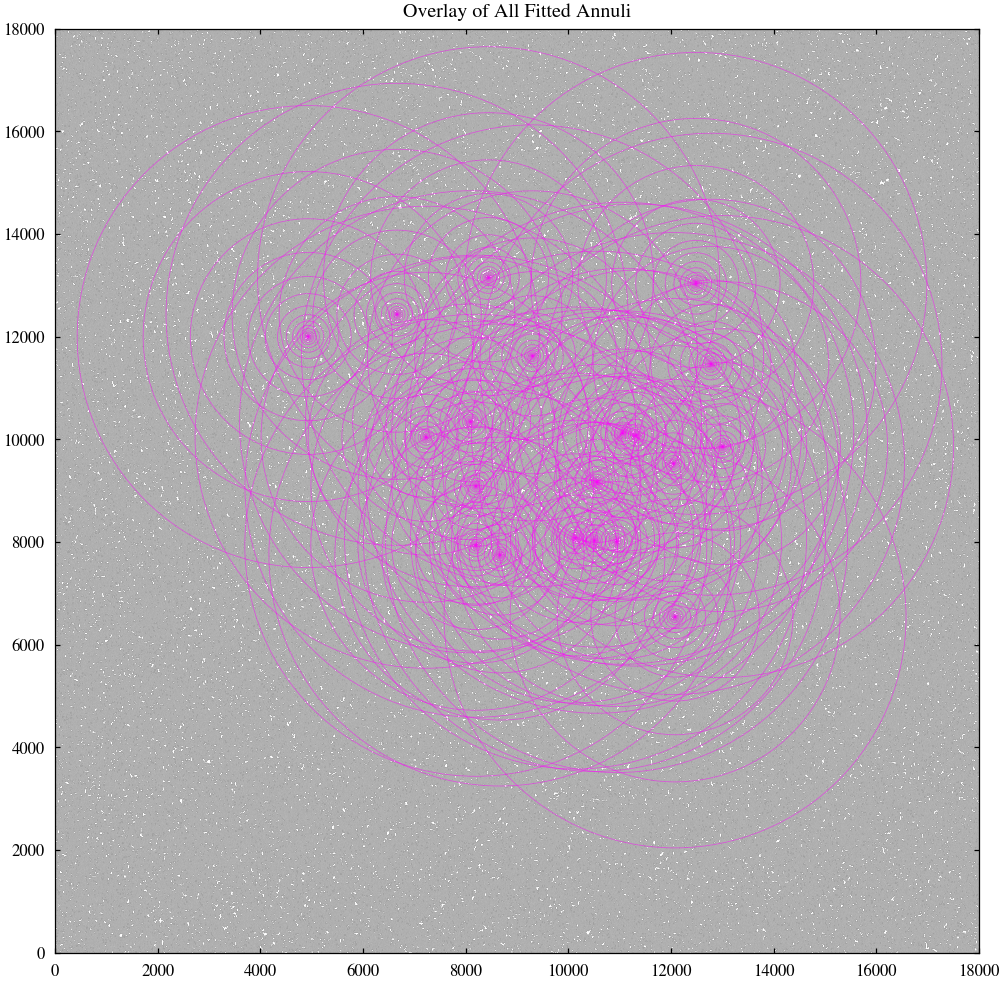

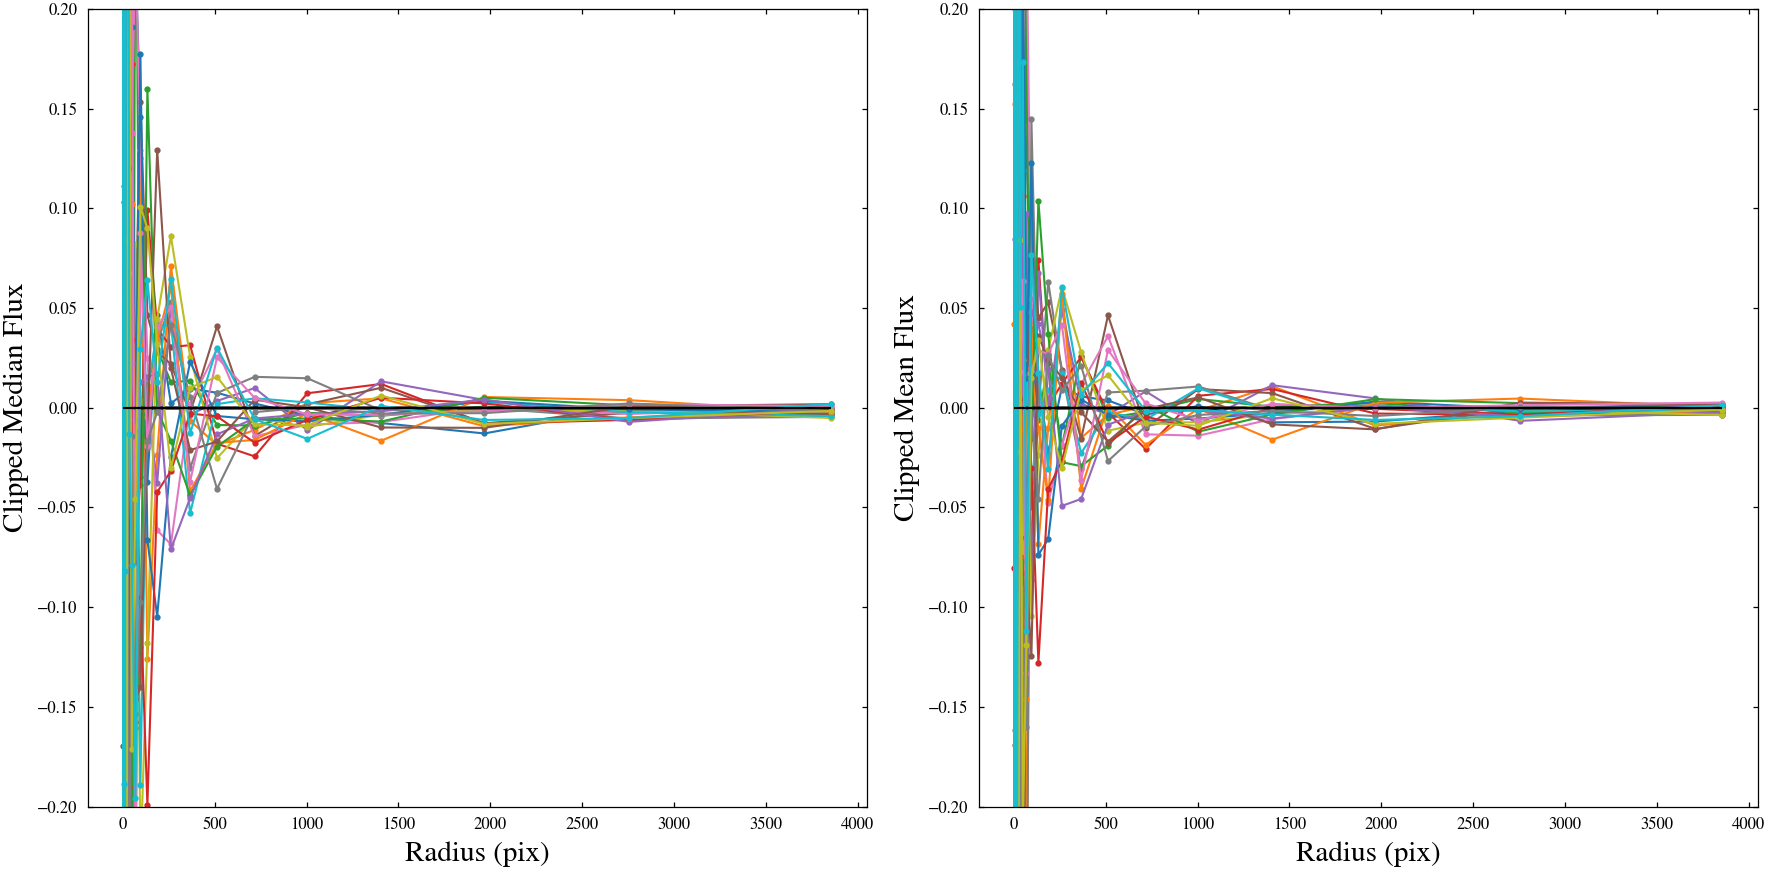

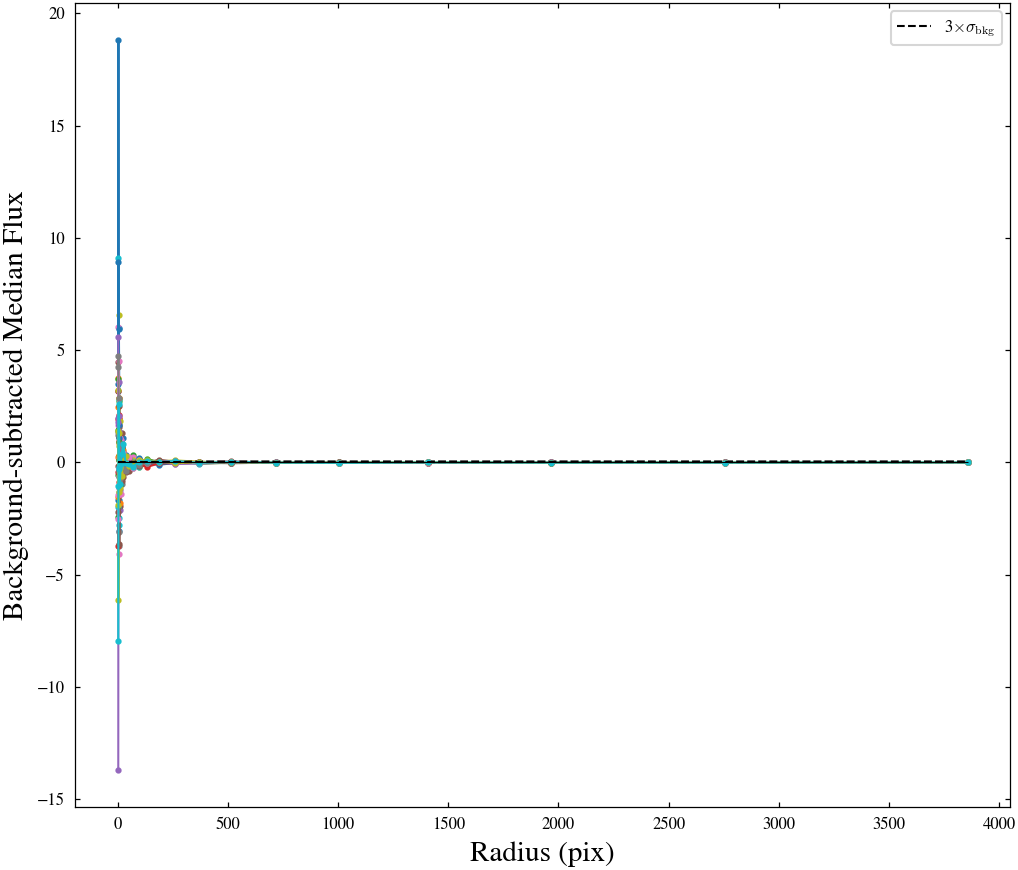

/tmp/ipykernel_3838314/2581019373.py:252: RuntimeWarning: divide by zero encountered in log10
  def flux_to_mag(flux): return zp - 2.5 * np.log10(flux)


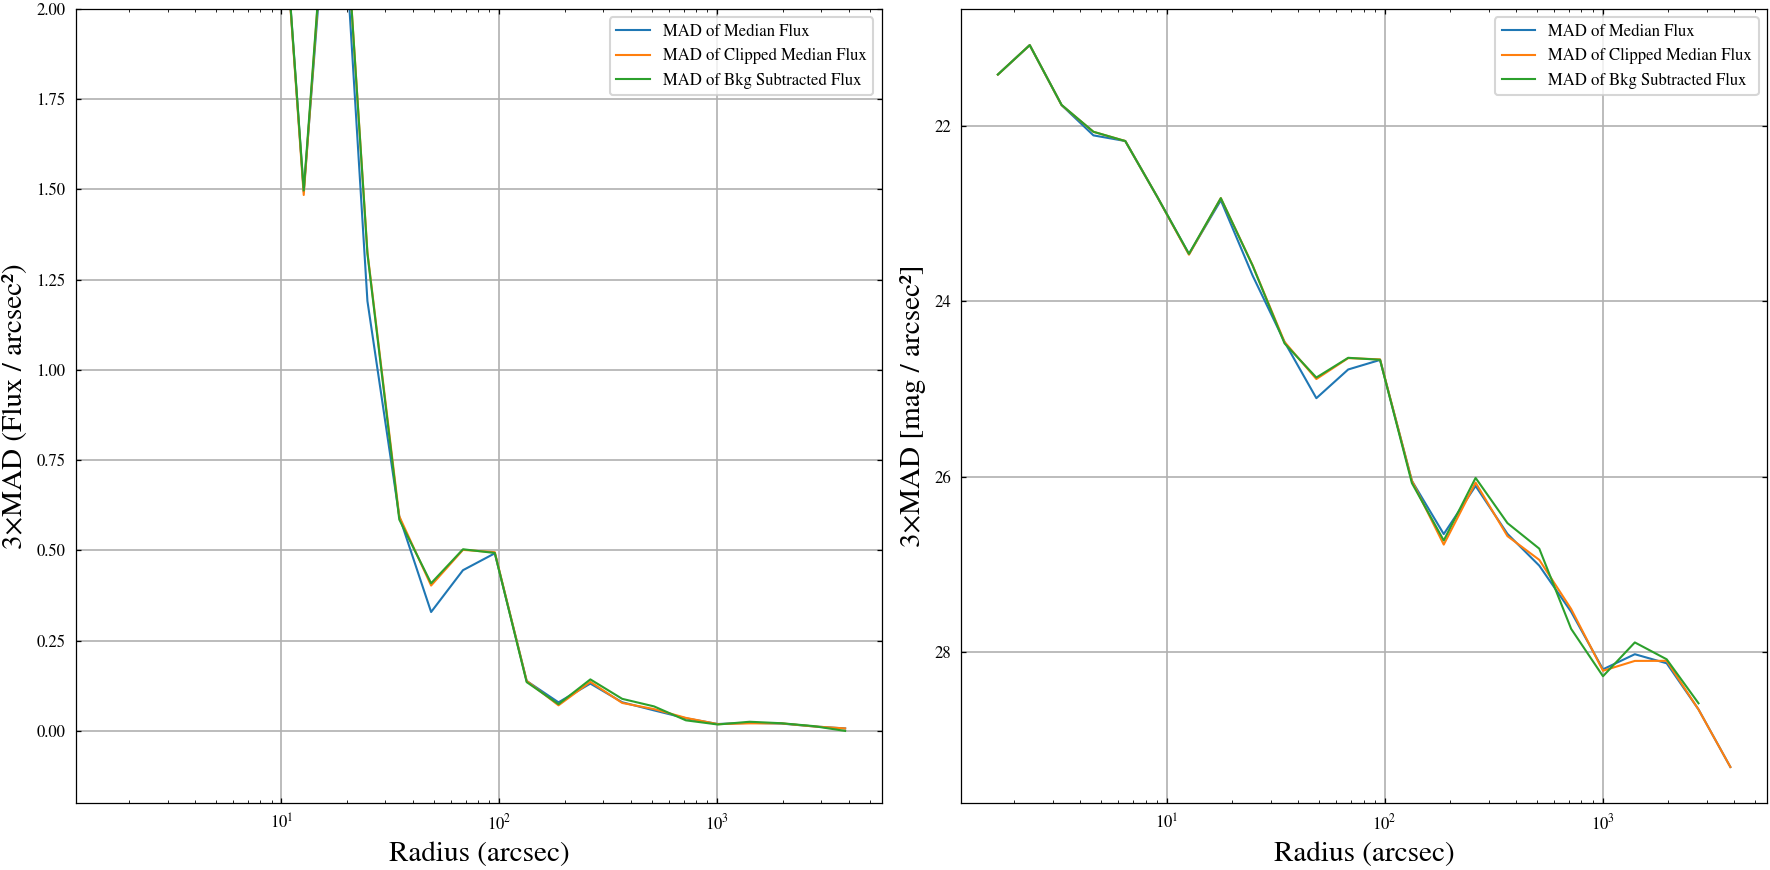

Finished plotting noise diagnostics.
Finished processing the file with gscale 0.4


In [ ]:
profileDir = Path("/home/ppztk1/Erosita/Outputs_Clusters/cluster/autoprof_results/")
outputDir = Path("/home/ppztk1/Erosita/Outputs_Clusters/background_test/")


bands = ["H"]

for band in bands:
    print(f"Processing the ")

    prof_path = profileDir / f"cluster_{band}_random_field_growth_0.25.prof"
    verbose = f"test_random_noise"

    image_path = outputDir / "test_random_noise.fits"
    mask_path = outputDir / "test_mask.fits"

    print(image_path)

    flux_combined_df, noise_measurements, label = measure_noise_in_circular_annuli(
        image_path=image_path,
        object_mask_path=mask_path,
        profile_path=prof_path,
        hdul_index=0,
        pixelscale=0.3,
        num_points=20,
        output_path=outputDir,
        verbose=verbose,
        show_annuli=True,
        show_diagnostic_plots=True,
        save_diagnostics=False,
    )

    print(f"Finished processing the file with gscale {gscale}")